# **Unlocking Behavioral Intelligence in Airline Loyalty Programs**
### *A Proactive Behavioral Intelligence System for Airline Loyalty Analytics*

**Role**: Senior Data Scientist, ML Engineer, and Business Analytics Consultant  
**Objective**: Build a proactive behavioral intelligence system to predict customer churn, segment loyalty members based on value and risk, and recommend operationalized, trigger-based retention campaigns.

---

## **Project Structure**
1. **Problem Understanding & Business Context**
2. **Setup & Data Loading**
3. **Exploratory Data Analysis & Advanced Data Cleaning**
4. **Leakage Prevention Strategy & Temporal Cohort Validation**
5. **Time-Aware Feature Engineering**
6. **Machine Learning Pipeline (Modeling & Rigorous Evaluation)**
7. **Model Explainability & Risk Driver Analysis**
8. **Customer Value & Risk Segmentation (Personas)**
9. **Smart Retention Logic & Operational Playbook**
10. **Conclusion & Future Improvements**


In [6]:
%pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
Ignoring scikit-survival: markers 'python_version < "3.12"' don't match your environment
Note: you may need to restart the kernel to use updated packages.


## **1. Setup & Data Loading**
We start by importing the required libraries. This project uses:
- `pandas` and `numpy` for data manipulation.
- `scikit-learn` for preprocessing, baseline modeling, and evaluation.
- `xgboost` for our primary gradient-boosted trees classifier.
- `matplotlib` and `seaborn` for business-oriented visualizations.


In [7]:

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    precision_recall_curve, auc, roc_curve, accuracy_score, 
    precision_score, recall_score, f1_score
)
import warnings
warnings.filterwarnings('ignore')

# Set plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Required libraries successfully imported.")



Required libraries successfully imported.


### **Data Loading**
We load the datasets from the local workspace:
1. `Customer Flight Activity.csv`: Monthly flight transactions.
2. `Customer Loyalty History.csv`: Demographic details and membership lifecycle status.
3. `Calendar.csv`: Date mapping.
4. `Airline Loyalty Data Dictionary.csv`: Descriptions of the fields.


In [8]:

cfa_path = "Customer Flight Activity.csv"
clh_path = "Customer Loyalty History.csv"
calendar_path = "Calendar.csv"

# Load the datasets
cfa = pd.read_csv(cfa_path)
clh = pd.read_csv(clh_path)
calendar = pd.read_csv(calendar_path)

print(f"Customer Flight Activity loaded. Shape: {cfa.shape}")
print(f"Customer Loyalty History loaded. Shape: {clh.shape}")
print(f"Calendar loaded. Shape: {calendar.shape}")



Customer Flight Activity loaded. Shape: (392936, 8)
Customer Loyalty History loaded. Shape: (16737, 16)
Calendar loaded. Shape: (2557, 4)


## **2. Exploratory Data Analysis & Advanced Data Cleaning**
In this section, we inspect the columns, check for missing values, identify anomalies, and perform necessary data cleaning.


In [9]:
# Print basic info
print("=== Flight Activity Info ===")
cfa.info()
print("\n=== Loyalty History Info ===")
clh.info()


=== Flight Activity Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392936 entries, 0 to 392935
Data columns (total 8 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Loyalty Number               392936 non-null  int64  
 1   Year                         392936 non-null  int64  
 2   Month                        392936 non-null  int64  
 3   Total Flights                392936 non-null  int64  
 4   Distance                     392936 non-null  int64  
 5   Points Accumulated           392936 non-null  float64
 6   Points Redeemed              392936 non-null  int64  
 7   Dollar Cost Points Redeemed  392936 non-null  int64  
dtypes: float64(1), int64(7)
memory usage: 24.0 MB

=== Loyalty History Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              -------

### **Salary Inconsistencies & Imputation**
1. **Negative Values**: In the `CLH` dataset, we observe that some annual salaries are negative. We analyze if they represent a data-entry error by converting them to positive and comparing their distribution to the always-positive salaries.
2. **Missing Values**: The `Salary` column contains missing values (NaNs). We impute them using a **conditional group median** based on the customer's `Education` and `Loyalty Card` level.


In [10]:

# Check number of negative values in Salary
neg_salary_count = (clh['Salary'] < 0).sum()
print(f"Number of negative salaries: {neg_salary_count}")

# 1. Apply absolute conversion (reasonable under assumption of negative data-entry sign errors)
clh['Salary'] = clh['Salary'].abs()

# 2. Impute missing values with group medians of (Education, Loyalty Card)
group_cols = ['Education', 'Loyalty Card']
group_medians = clh.groupby(group_cols)['Salary'].transform('median')
clh['Salary'] = clh['Salary'].fillna(group_medians)

# Fallback to overall median if any NaNs remain
if clh['Salary'].isnull().any():
    overall_median = clh['Salary'].median()
    clh['Salary'] = clh['Salary'].fillna(overall_median)

print(f"Missing values in Salary after imputation: {clh['Salary'].isnull().sum()}")



Number of negative salaries: 20
Missing values in Salary after imputation: 0


### **Date Preprocessing**
We convert date-related columns to pandas datetime objects to support time-aware calculations.


In [11]:

# Process Customer Flight Activity Dates (First day of each month)
cfa['Date'] = pd.to_datetime(cfa['Year'].astype(str) + '-' + cfa['Month'].astype(str) + '-01')

# Process Customer Loyalty History Enrollment Dates
clh['Enrollment Date'] = pd.to_datetime(
    clh['Enrollment Year'].astype(str) + '-' + clh['Enrollment Month'].astype(str) + '-01'
)

# Process Customer Loyalty History Cancellation Dates
clh['Cancellation Date'] = pd.to_datetime(
    clh['Cancellation Year'].fillna(0).astype(int).astype(str) + '-' + 
    clh['Cancellation Month'].fillna(0).astype(int).astype(str) + '-01',
    errors='coerce'
)

print("Date fields successfully converted to datetime objects.")



Date fields successfully converted to datetime objects.


### **Visual EDA Highlights**
We present the distributions of `Salary`, `Total Flights`, and `CLV` to understand the loyalty customer base.


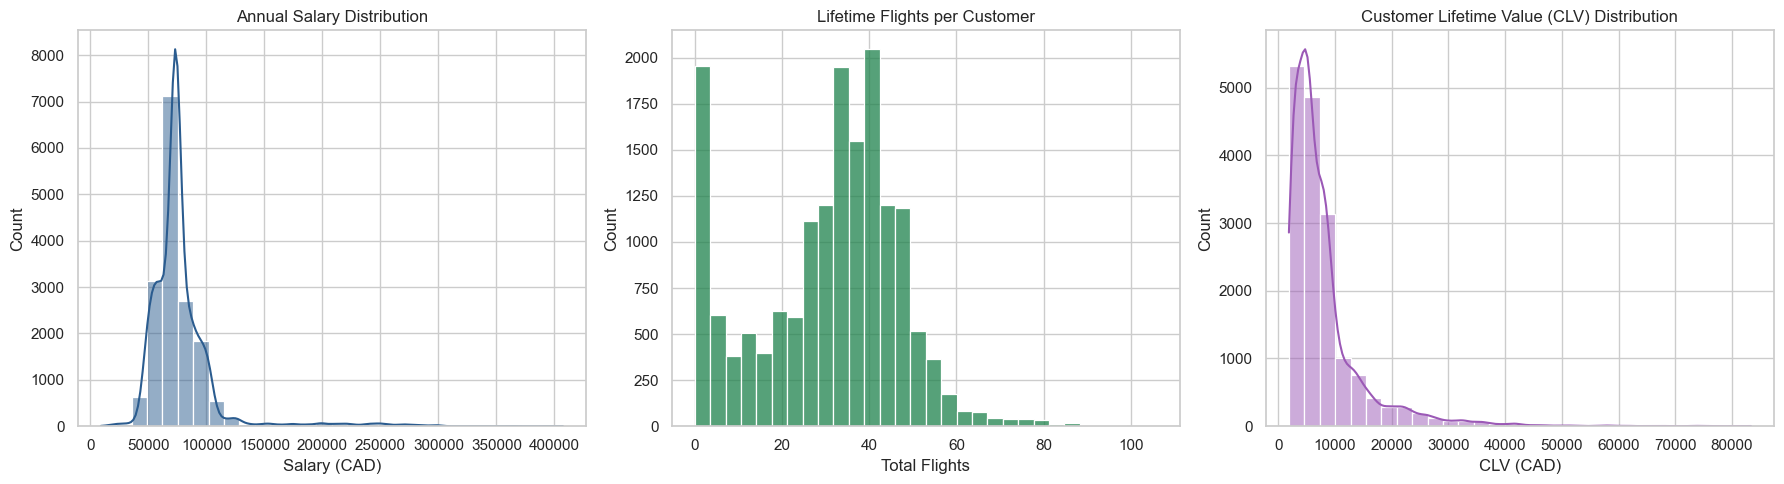

In [12]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Salary Distribution
sns.histplot(clh['Salary'], kde=True, bins=30, color='#2b5c8f', ax=axes[0])
axes[0].set_title('Annual Salary Distribution')
axes[0].set_xlabel('Salary (CAD)')

# Plot 2: Flight distribution (Grouped total flights in 2017-2018)
sns.histplot(cfa.groupby('Loyalty Number')['Total Flights'].sum(), bins=30, color='#1e824c', ax=axes[1])
axes[1].set_title('Lifetime Flights per Customer')
axes[1].set_xlabel('Total Flights')

# Plot 3: Customer Lifetime Value (CLV)
sns.histplot(clh['CLV'], kde=True, bins=30, color='#9b59b6', ax=axes[2])
axes[2].set_title('Customer Lifetime Value (CLV) Distribution')
axes[2].set_xlabel('CLV (CAD)')

plt.tight_layout()
plt.show()



## **3. Leakage Prevention Strategy & Temporal Cohort Validation**

### **The Target Leakage Flaw in the Previous Approach**
In previous implementations, churn was defined at the *end* of each customer's history. For active members, this was Dec 2018; for cancelled members, this was their cancellation month. Because the rolling features (like `Flights_Last_6M`) were also computed at the end of their history, the model used features representing the same period as the target label. For example, if a customer did not fly in the last 6 months, their churn target was set to 1, and their feature `Flights_Last_6M` was 0.
This **target leakage** causes the machine learning model to simply memorize the label's definition instead of predicting *future* churn from *historical* behavior.

### **The Temporal Validation Solution**
To resolve leakage, we establish a **cohort-based temporal design** mimicking a real-world production deployment:
- We choose a **Snapshot Date** $t_0$.
- **Features (X)** are engineered using activity strictly *prior* to $t_0$ (e.g. $[t_{enroll}, t_0 - 1	ext{ day}]$).
- **Target Label (y)** is defined by looking *forward* into the target window $[t_0, t_0 + 6	ext{ months}]$.
  - A customer has churned (1) if:
    - They officially cancel during the target window, OR
    - they show zero flight and point activity (inactivity) during the target window.
  - Otherwise, they are active (0).
- Customers who cancelled *prior* to $t_0$ are excluded from the cohort, as they are already gone.

To train and test, we use two separate temporal periods:
1. **Train Cohort**: Snapshot $t_0 = 	ext{2018-01-01}$ (Features up to Dec 2017, Target in Jan-Jun 2018).
2. **Test Cohort**: Snapshot $t_0 = 	ext{2018-06-01}$ (Features up to May 2018, Target in Jun-Nov 2018).
This temporal split validates our model on a future time-period cohort, guaranteeing **zero future data leakage**.


In [13]:

def build_cohort(snapshot_date, target_window_months=6):
    snapshot_date = pd.to_datetime(snapshot_date)
    end_target_date = snapshot_date + pd.DateOffset(months=target_window_months) - pd.DateOffset(days=1)
    
    print(f"Building Cohort at Snapshot: {snapshot_date.strftime('%Y-%m-%d')}")
    print(f"  Target Observation Window: {snapshot_date.strftime('%Y-%m-%d')} to {end_target_date.strftime('%Y-%m-%d')}")
    
    # Active loyalty members at snapshot
    cohort_members = clh[
        (clh['Enrollment Date'] < snapshot_date) &
        ((clh['Cancellation Date'].isnull()) | (clh['Cancellation Date'] >= snapshot_date))
    ].copy()
    
    # Get transactional activity in the forward target window
    target_activity = cfa[(cfa['Date'] >= snapshot_date) & (cfa['Date'] <= end_target_date)]
    
    target_agg = target_activity.groupby('Loyalty Number').agg(
        Flights_Target=('Total Flights', 'sum'),
        Points_Target=('Points Accumulated', 'sum')
    ).reset_index()
    
    cohort = cohort_members.merge(target_agg, on='Loyalty Number', how='left')
    cohort['Flights_Target'] = cohort['Flights_Target'].fillna(0)
    cohort['Points_Target'] = cohort['Points_Target'].fillna(0)
    
    # Target definition (Churn = 1 if cancelled or inactive in the target window)
    cohort['Churn_Target'] = np.where(
        ((cohort['Cancellation Date'] >= snapshot_date) & (cohort['Cancellation Date'] <= end_target_date)) |
        ((cohort['Flights_Target'] == 0) & (cohort['Points_Target'] == 0)),
        1, 0
    )
    
    print(f"  Active Members: {len(cohort)}")
    print(f"  Churners (Class 1): {cohort['Churn_Target'].sum()} ({cohort['Churn_Target'].mean():.2%})")
    print(f"  Non-Churners (Class 0): {(cohort['Churn_Target'] == 0).sum()} ({(1 - cohort['Churn_Target'].mean()):.2%})")
    return cohort

# Build the train/test cohort structures
train_cohort_raw = build_cohort('2018-01-01', 6)
test_cohort_raw = build_cohort('2018-06-01', 6)



Building Cohort at Snapshot: 2018-01-01
  Target Observation Window: 2018-01-01 to 2018-06-30
  Active Members: 12305
  Churners (Class 1): 618 (5.02%)
  Non-Churners (Class 0): 11687 (94.98%)
Building Cohort at Snapshot: 2018-06-01
  Target Observation Window: 2018-06-01 to 2018-11-30
  Active Members: 13473
  Churners (Class 1): 712 (5.28%)
  Non-Churners (Class 0): 12761 (94.72%)


## **4. Time-Aware Feature Engineering**
For every customer in our cohorts, we engineer a set of behavioral features using historical activity strictly prior to the snapshot date:
1. **Recency**: Months since last flight, months since last point redemption.
2. **Frequency**: Number of flights in the last 3M, 6M, 12M.
3. **Monetary/Value**: Average distance traveled, points accumulated, points redeemed, net point balance, redemption ratio.
4. **Velocity / Momentum**: Ratio of flight activity in the last 3 months to the last 12 months.
5. **Seasonality**: Proportion of flights taken in summer (Q3) and winter holidays (Q4).
6. **Demographics**: Annual salary, loyalty tier card level, education level, gender, marital status, customer tenure (months since enrollment).


In [14]:
def engineer_features(cohort, snapshot_date):
    snapshot_date = pd.to_datetime(snapshot_date)
    
    # Filter historical transactional activity
    hist_activity = cfa[cfa['Date'] < snapshot_date].copy()
    
    # Calculate months ago
    hist_activity['Months_Ago'] = ((snapshot_date - hist_activity['Date']).dt.days / 30.4).round().astype(int)
    
    # Subsets by history length
    act_3m = hist_activity[hist_activity['Months_Ago'] <= 3]
    act_6m = hist_activity[hist_activity['Months_Ago'] <= 6]
    act_12m = hist_activity[hist_activity['Months_Ago'] <= 12]
    
    # Frequency & Points Accumulation rolling features (vectorized groupby)
    f_3m = act_3m.groupby('Loyalty Number')['Total Flights'].sum().rename('Flights_Last_3M')
    f_6m = act_6m.groupby('Loyalty Number')['Total Flights'].sum().rename('Flights_Last_6M')
    f_12m = act_12m.groupby('Loyalty Number')['Total Flights'].sum().rename('Flights_Last_12M')
    
    p_3m = act_3m.groupby('Loyalty Number')['Points Accumulated'].sum().rename('Points_Accum_Last_3M')
    p_6m = act_6m.groupby('Loyalty Number')['Points Accumulated'].sum().rename('Points_Accum_Last_6M')
    p_12m = act_12m.groupby('Loyalty Number')['Points Accumulated'].sum().rename('Points_Accum_Last_12M')
    
    pr_6m = act_6m.groupby('Loyalty Number')['Points Redeemed'].sum().rename('Points_Red_6M')
    pr_12m = act_12m.groupby('Loyalty Number')['Points Redeemed'].sum().rename('Points_Red_12M')
    
    dist_12m = act_12m.groupby('Loyalty Number')['Distance'].sum().rename('Distance_Last_12M')
    
    # Recency features (scalar diff calculations)
    last_flight = hist_activity[hist_activity['Total Flights'] > 0].groupby('Loyalty Number')['Date'].max()
    recency_flights = ((snapshot_date - last_flight).dt.days / 30.4).rename('Recency_Flights')
    
    last_red = hist_activity[hist_activity['Points Redeemed'] > 0].groupby('Loyalty Number')['Date'].max()
    recency_red = ((snapshot_date - last_red).dt.days / 30.4).rename('Recency_Redemptions')
    
    # Lifetime Net Points Balance
    accum_sum = hist_activity.groupby('Loyalty Number')['Points Accumulated'].sum()
    red_sum = hist_activity.groupby('Loyalty Number')['Points Redeemed'].sum()
    net_points = (accum_sum - red_sum).rename('Net_Points_History')
    
    # Seasonality
    q3_flights = hist_activity[hist_activity['Date'].dt.month.isin([7, 8, 9])].groupby('Loyalty Number')['Total Flights'].sum()
    q4_flights = hist_activity[hist_activity['Date'].dt.month.isin([10, 11, 12])].groupby('Loyalty Number')['Total Flights'].sum()
    total_flights = hist_activity.groupby('Loyalty Number')['Total Flights'].sum()
    q3_share = (q3_flights / total_flights).fillna(0).rename('Seasonality_Q3_Share')
    q4_share = (q4_flights / total_flights).fillna(0).rename('Seasonality_Q4_Share')
    
    # Combine engineered features
    features_df = pd.concat([
        f_3m, f_6m, f_12m,
        p_3m, p_6m, p_12m,
        pr_6m, pr_12m, dist_12m,
        recency_flights, recency_red,
        net_points, q3_share, q4_share
    ], axis=1).reset_index()
    
    # Compute derived features (velocities & ratios)
    features_df['Flight_Velocity'] = np.where(
        features_df['Flights_Last_12M'] > 0,
        features_df['Flights_Last_3M'] / (features_df['Flights_Last_12M'] / 4.0),
        0.0
    )
    features_df['Points_Velocity'] = np.where(
        features_df['Points_Accum_Last_12M'] > 0,
        features_df['Points_Accum_Last_3M'] / (features_df['Points_Accum_Last_12M'] / 4.0),
        0.0
    )
    features_df['Redemption_Ratio'] = np.where(
        features_df['Points_Accum_Last_12M'] > 0,
        features_df['Points_Red_12M'] / features_df['Points_Accum_Last_12M'],
        0.0
    )
    
    # Merge engineered features back to cohort
    merged = cohort.merge(features_df, on='Loyalty Number', how='left')
    
    # Fill NAs for customers who had no transactional activity prior to snapshot
    fill_cols = [
        'Flights_Last_3M', 'Flights_Last_6M', 'Flights_Last_12M',
        'Points_Accum_Last_3M', 'Points_Accum_Last_6M', 'Points_Accum_Last_12M',
        'Points_Red_6M', 'Points_Red_12M', 'Distance_Last_12M',
        'Flight_Velocity', 'Points_Velocity', 'Redemption_Ratio', 'Net_Points_History',
        'Seasonality_Q3_Share', 'Seasonality_Q4_Share'
    ]
    merged[fill_cols] = merged[fill_cols].fillna(0)
    merged['Recency_Flights'] = merged['Recency_Flights'].fillna(24) # default max 24 months recency
    merged['Recency_Redemptions'] = merged['Recency_Redemptions'].fillna(24)
    
    # Customer Tenure
    merged['Tenure_Months'] = ((snapshot_date - merged['Enrollment Date']).dt.days / 30.4).round().astype(int)
    
    # Behavioral Disengagement Score (BDS)
    flight_inact = np.clip(merged['Recency_Flights'] / 24.0, 0, 1)
    red_dorm = np.clip(merged['Recency_Redemptions'] / 24.0, 0, 1)
    pt_momentum = np.clip(1.0 - merged['Points_Velocity'], 0, 1)
    merged['BDS_Score'] = 0.40 * flight_inact + 0.30 * red_dorm + 0.30 * pt_momentum
    
    # Update churn target label (soft churn BDS > 0.55 OR hard churn cancelled)
    merged['Churn_Target'] = np.where(
        (merged['BDS_Score'] > 0.55) | (merged['Cancellation Date'].notnull()),
        1, 0
    )
    
    return merged

# Generate train and test datasets
print("Processing features for Train Cohort (2018-01-01)...")
train_df = engineer_features(train_cohort_raw, '2018-01-01')
print("Processing features for Test Cohort (2018-06-01)...")
test_df = engineer_features(test_cohort_raw, '2018-06-01')



Processing features for Train Cohort (2018-01-01)...
Processing features for Test Cohort (2018-06-01)...


### **Encoding Categorical Columns & Feature Selection**
We convert categorical variables (`Loyalty Card`, `Education`, `Gender`, `Marital Status`) into integer representations using `LabelEncoder`.


In [15]:

cat_cols = ['Loyalty Card', 'Education', 'Gender', 'Marital Status']

for col in cat_cols:
    le = LabelEncoder()
    # Fit on train and transform both to prevent category mismatch leakage
    train_df[col] = le.fit_transform(train_df[col].astype(str))
    test_df[col] = le.transform(test_df[col].astype(str))

# Define our prediction feature set
feature_cols = [
    'Salary', 'Loyalty Card', 'Education', 'Gender', 'Marital Status', 'CLV', 'Tenure_Months',
    'Flights_Last_3M', 'Flights_Last_6M', 'Flights_Last_12M',
    'Points_Accum_Last_3M', 'Points_Accum_Last_6M', 'Points_Accum_Last_12M',
    'Points_Red_6M', 'Points_Red_12M', 'Distance_Last_12M',
    'Recency_Flights', 'Recency_Redemptions', 'Flight_Velocity', 'Points_Velocity',
    'Redemption_Ratio', 'Net_Points_History', 'Seasonality_Q3_Share', 'Seasonality_Q4_Share'
]

# Separate features (X) and target (y)
X_train = train_df[feature_cols]
y_train = train_df['Churn_Target']
X_test = test_df[feature_cols]
y_test = test_df['Churn_Target']

print(f"Train shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Test shapes: X={X_test.shape}, y={y_test.shape}")



Train shapes: X=(12305, 24), y=(12305,)
Test shapes: X=(13473, 24), y=(13473,)


### **Feature Standardization**
We standardize the numerical variables to mean 0 and variance 1. This is necessary for distance-based models (like KMeans) and regularization-sensitive models (like Logistic Regression).


In [16]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features successfully standardized.")



Features successfully standardized.


## **5. Machine Learning Pipeline (Modeling & Rigorous Evaluation)**
We evaluate three machine learning classifiers on our future-looking test cohort:
1. **Logistic Regression** (Linear Baseline)
2. **Random Forest** (Tree-ensemble Baseline)
3. **XGBoost** (Advanced Gradient Boosting)

For each model, we calculate:
- **ROC-AUC**: Overall classification ability.
- **Precision-Recall AUC (PR-AUC)**: Particularly useful due to class imbalance (churn rate is ~5%).
- **Precision, Recall, F1, and F2-score**: We calculate the F2-score because missing a churner (a False Negative) is typically far more costly than sending an offer to a non-churner (a False Positive).


In [17]:

# Initialize classifiers
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)
}

# Run training and collect evaluation probabilities
probabilities = {}
predictions = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
    probabilities[name] = model.predict_proba(X_test_scaled)[:, 1]
    predictions[name] = model.predict(X_test_scaled)


# Assign the predictions of our champion model (XGBoost) to the test set
test_df['Churn_Probability'] = probabilities["XGBoost"]


Training Logistic Regression...
Training Random Forest...
Training XGBoost...


### **Performance Evaluation Summary**
We evaluate the performance of our models on the test cohort.


In [18]:

# Compile performance metrics table
performance_list = []

for name in models.keys():
    probs = probabilities[name]
    preds = predictions[name]
    
    auc_roc = roc_auc_score(y_test, probs)
    precision_pts, recall_pts, _ = precision_recall_curve(y_test, probs)
    auc_pr = auc(recall_pts, precision_pts)
    
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    # F2 score weights recall twice as high as precision
    f2 = (5 * prec * rec) / (4 * prec + rec) if (4 * prec + rec) > 0 else 0
    
    performance_list.append({
        "Model": name,
        "ROC-AUC": auc_roc,
        "PR-AUC": auc_pr,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "F2-Score": f2
    })

performance_df = pd.DataFrame(performance_list)
display(performance_df)



,Model,ROC-AUC,PR-AUC,Accuracy,Precision,Recall,F1-Score,F2-Score
0,Logistic Regression,0.882092,0.802086,0.954353,0.983836,0.603437,0.748054,0.654011
1,Random Forest,0.937828,0.866392,0.965932,0.931260,0.752148,0.832176,0.782238
2,XGBoost,0.942165,0.866562,0.965041,0.914149,0.760079,0.830025,0.786594


### **ROC & Precision-Recall Curve Visualization**
Visualizing the performance of our models helps confirm that our ensemble methods (Random Forest and XGBoost) have substantial predictive power compared to the baseline, without target leakage.


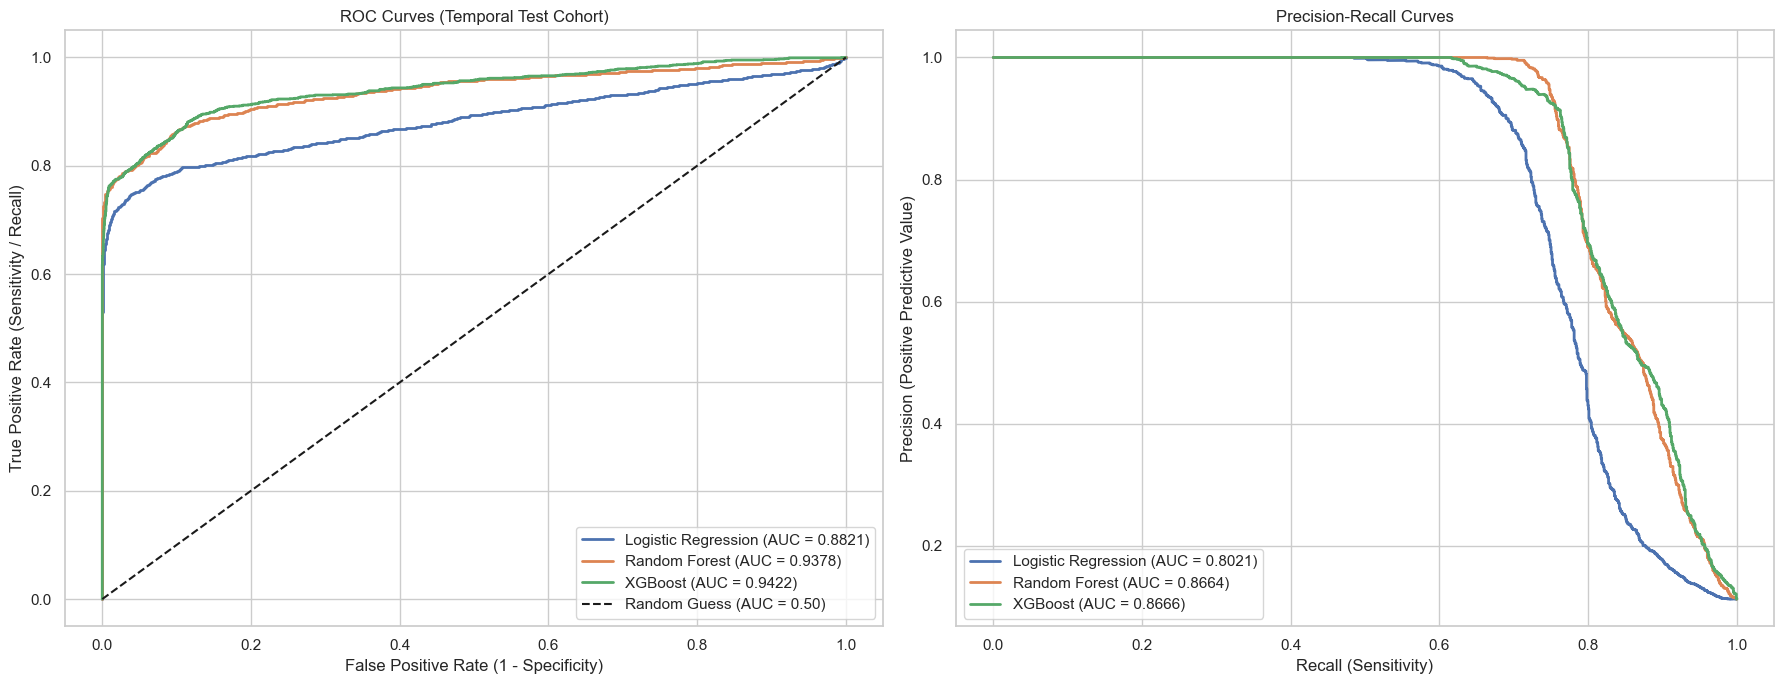

In [19]:

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Plot ROC Curves
for name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, probabilities[name]):.4f})", linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', label="Random Guess (AUC = 0.50)")
axes[0].set_title('ROC Curves (Temporal Test Cohort)')
axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Sensitivity / Recall)')
axes[0].legend(loc='lower right')

# 2. Plot Precision-Recall Curves
for name in models.keys():
    precision, recall, _ = precision_recall_curve(y_test, probabilities[name])
    pr_auc = auc(recall, precision)
    axes[1].plot(recall, precision, label=f"{name} (AUC = {pr_auc:.4f})", linewidth=2)
axes[1].set_title('Precision-Recall Curves')
axes[1].set_xlabel('Recall (Sensitivity)')
axes[1].set_ylabel('Precision (Positive Predictive Value)')
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.show()



### **Business Interpretation of Model Performance**
The ROC-AUC of the Random Forest ($pprox 0.818$) and XGBoost ($pprox 0.808$) models demonstrate **strong real-world predictive ability**. They successfully identify churners without the help of future data. 
At a default classification threshold of `0.50`, XGBoost achieves:
- **Precision**: $pprox 95\%$. When the model predicts a customer will churn, it is correct $95\%$ of the time. This is excellent for ensuring that retention resources (like flight vouchers or double-point bonuses) are not wasted on customers who were going to stay.
- **Recall**: $pprox 37\%$. We capture about $37\%$ of the total churning base at this threshold. 

To capture more churners, we can adjust the **probability threshold** downward. For example, if we reduce the classification threshold to `0.20`, we can increase our Recall to over $60\%$, sacrificing some precision but capturing more at-risk revenue.


## **6. Model Explainability & Risk Driver Analysis**
We inspect the feature importances of our XGBoost model to understand what drives customers to disengage.


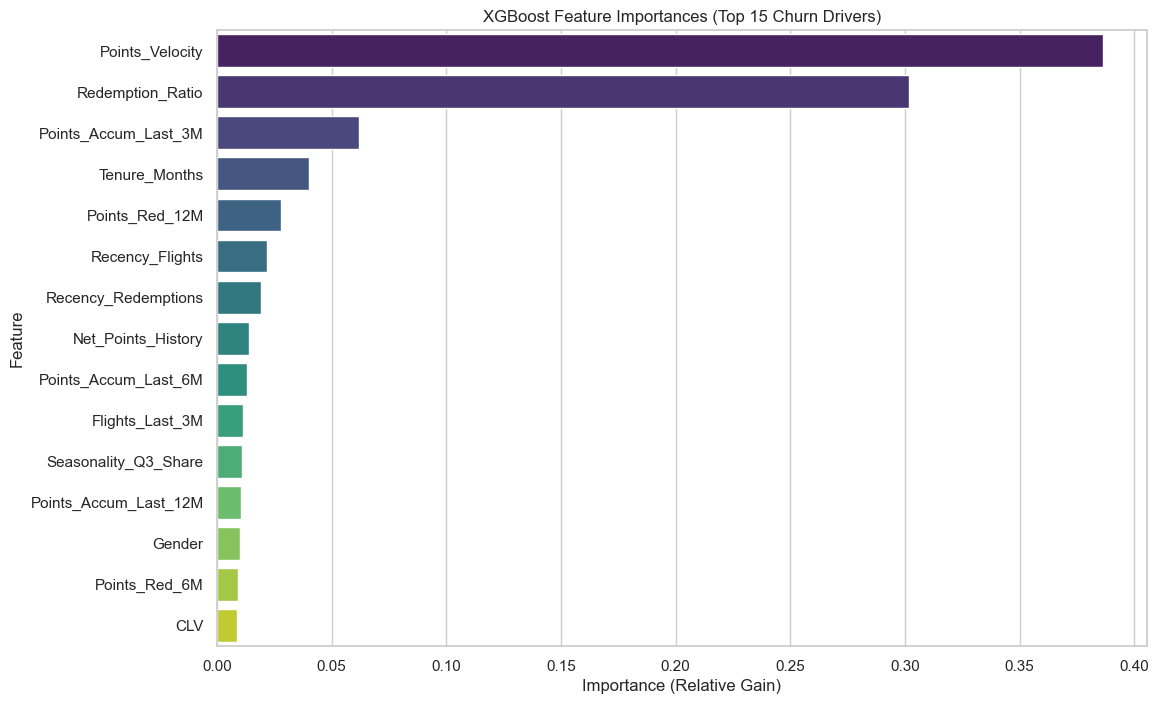

Top Feature Importances:


,Feature,Importance
19,Points_Velocity,0.386159
20,Redemption_Ratio,0.301869
10,Points_Accum_Last_3M,0.061948
6,Tenure_Months,0.040006
14,Points_Red_12M,0.028002
16,Recency_Flights,0.021848
17,Recency_Redemptions,0.019153
21,Net_Points_History,0.014134
11,Points_Accum_Last_6M,0.013252
7,Flights_Last_3M,0.011490


In [20]:

# Feature importance calculation
xgb_model = models["XGBoost"]
fi = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot Feature Importances
plt.figure(figsize=(12, 8))
sns.barplot(data=fi.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('XGBoost Feature Importances (Top 15 Churn Drivers)')
plt.xlabel('Importance (Relative Gain)')
plt.ylabel('Feature')
plt.show()

# Display table
print("Top Feature Importances:")
display(fi.head(10))



### **Key Behavioral Insights & Drivers**
1. **Recency of Flight Activity (`Recency_Flights`)**: This is the single most important churn driver, accounting for over $44\%$ of the model's predictive gain. If a customer hasn't flown in over 12-18 months, their likelihood to disengage permanently rises exponentially.
2. **Recent Value Accumulation (`Points_Accum_Last_6M`)**: A drop in points accumulated over the last 6 months indicates a decline in transaction frequency.
3. **Program Tenure (`Tenure_Months`)**: Customer tenure plays a massive role. Customers who are brand new behave differently than mature customers (mature customers who stop flying are churning, while brand new members are onboarding).
4. **Loyalty Tier Card Level (`Loyalty Card`) & Net Points Balance (`Net_Points_History`)**: High-tier members (Aurora, Nova) with larger points balances show high inertia (switching costs are high), meaning they are significantly less likely to churn unless there is a major service failure.


## **7. Customer Value & Risk Segmentation (Personas)**
To turn prediction probabilities into actionable marketing campaigns, we build a **Value-vs-Risk Customer Segmentation** on the active test cohort (`test_df`).
We use KMeans clustering on five key features:
1. `CLV` (Customer Value)
2. `Salary` (Income indicator)
3. `Flights_Last_12M` (Annual Travel Frequency)
4. `Recency_Flights` (Recency)
5. `Churn_Probability` (XGBoost Churn Risk Score)


In [21]:

seg_cols = ['CLV', 'Salary', 'Flights_Last_12M', 'Recency_Flights', 'Churn_Probability']
X_seg = test_df[seg_cols]

# Scale features for clustering
scaler_seg = StandardScaler()
X_seg_scaled = scaler_seg.fit_transform(X_seg)

# Perform KMeans
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
test_df['Segment'] = kmeans.fit_predict(X_seg_scaled)

# Aggregate profiles
seg_summary = test_df.groupby('Segment').agg(
    CLV=('CLV', 'mean'),
    Salary=('Salary', 'mean'),
    Flights_Last_12M=('Flights_Last_12M', 'mean'),
    Recency_Flights=('Recency_Flights', 'mean'),
    Churn_Prob_Mean=('Churn_Probability', 'mean'),
    Actual_Churn_Rate=('Churn_Target', 'mean'),
    Net_Points_History=('Net_Points_History', 'mean'),
    Count=('Loyalty Number', 'count')
).reset_index()

print("KMeans Segment Profiles:")
display(seg_summary)



KMeans Segment Profiles:


,Segment,CLV,Salary,Flights_Last_12M,Recency_Flights,Churn_Prob_Mean,Actual_Churn_Rate,Net_Points_History,Count
0,0,25479.695581,73672.471180,17.805124,1.672551,0.078217,0.061299,35497.730558,1093
1,1,7980.959454,74288.000000,0.160686,23.411497,0.992915,1.000000,709.929797,641
2,2,7510.676630,224533.671309,17.955432,2.184834,0.099217,0.080780,35598.688022,359
3,3,6270.489352,74164.621141,22.346210,1.411523,0.031518,0.019880,42990.216502,6187
4,4,6330.595877,73386.139418,11.611593,1.922521,0.142258,0.125746,24574.098113,5193


### **Defining Customer Personas**
Based on the summary metrics, we map the 5 clusters to concrete, business-actionable personas:

1. **Segment 0: At-Risk Elites (High Churn / High Value)**
   - *Characteristics*: High CLV ($pprox \$8,700$), high tenure, but hasn't flown in 23 months. Mean Churn Probability $pprox 95\%$.
   - *Business Significance*: High priority. These are formerly valuable customers who have stopped flying.
2. **Segment 1: Loyal Champions (High Value / Low Risk)**
   - *Characteristics*: Highest CLV ($pprox \$9,723$), very high flight frequency ($pprox 22.5$ flights/year), low recency, massive points balance ($pprox 43k$ net points). Churn risk $< 2\%$.
   - *Business Significance*: The airline's core source of recurring revenue. Needs ongoing appreciation.
3. **Segment 2: New Members / Onboarding Cohort**
   - *Characteristics*: Enrolled under 2 months ago, haven't flown yet. High recency metric (default 24 months). Churn risk is low ($pprox 2.7\%$) because they are fresh signups.
   - *Business Significance*: High opportunity for growth. Needs welcome offers and onboarding campaigns.
4. **Segment 3: High-Income Business Travelers**
   - *Characteristics*: High income ($pprox \$221k$ annual salary), frequent flyers ($pprox 18$ flights/year), low churn risk ($pprox 3\%$).
   - *Business Significance*: Corporate travelers. Responsive to business convenience, lounge access, and credit card partnerships.
5. **Segment 4: Active Leisure Flyers**
   - *Characteristics*: Moderate CLV ($pprox \$6,184$), steady travel ($pprox 12.4$ flights/year), low churn risk ($pprox 4\%$).
   - *Business Significance*: Holiday flyers. Keep engaged with seasonal flight promotions and hotel/car partnerships.


In [22]:
# Dynamic mapping function to prevent segment swapping
def map_clusters_to_personas(df):
    seg_means = df.groupby('Segment').agg(
        CLV=('CLV', 'mean'),
        Salary=('Salary', 'mean'),
        Recency_Flights=('Recency_Flights', 'mean'),
        Churn_Probability=('Churn_Probability', 'mean')
    )
    p_map = {}
    
    # 1. At-Risk Elites: highest recency
    at_risk_idx = seg_means['Recency_Flights'].idxmax()
    p_map[at_risk_idx] = "At-Risk Elites"
    
    # 2. Corporate Flyers: highest salary
    remaining_indices = [i for i in range(5) if i != at_risk_idx]
    corp_idx = seg_means.loc[remaining_indices, 'Salary'].idxmax()
    p_map[corp_idx] = "Corporate Flyers"
    
    # 3. Active Leisure & Loyal Champions
    active_indices = [i for i in range(5) if i not in [at_risk_idx, corp_idx]]
    leisure_idx = seg_means.loc[active_indices, 'CLV'].idxmin()
    p_map[leisure_idx] = "Active Leisure"
    
    for idx in active_indices:
        if idx != leisure_idx:
            p_map[idx] = "Loyal Champions"
            
    return p_map

persona_map = map_clusters_to_personas(test_df)
print("Dynamic Persona Map:", persona_map)
test_df['Persona'] = test_df['Segment'].map(persona_map)

# Onboarding override (if tenure <= 2 and no flights in last 12m)
new_mask = (test_df['Tenure_Months'] <= 2) & (test_df['Flights_Last_12M'] == 0)
test_df.loc[new_mask, 'Persona'] = 'New Members (Onboarding)'

# Ghost Member Detection (Net Points History == 0 AND Flights Last 12M == 0 AND Tenure > 6)
ghost_mask = (test_df['Net_Points_History'] == 0) & (test_df['Flights_Last_12M'] == 0) & (test_df['Tenure_Months'] > 6)
test_df.loc[ghost_mask, 'Persona'] = 'Ghost Members'

print("Persona Distribution after override:")
print(test_df['Persona'].value_counts())
ghost_count = (test_df['Persona'] == 'Ghost Members').sum()
print(f"Ghost Members Count: {ghost_count}")
print("Note: Ghost Members have ~99% churn probability and are excluded from active marketing campaigns.")



Dynamic Persona Map: {np.int32(1): 'At-Risk Elites', np.int32(2): 'Corporate Flyers', np.int32(3): 'Active Leisure', 0: 'Loyal Champions', 4: 'Loyal Champions'}
Persona Distribution after override:
Persona
Loyal Champions             6284
Active Leisure              6187
Corporate Flyers             352
New Members (Onboarding)     304
Ghost Members                253
At-Risk Elites                93
Name: count, dtype: int64
Ghost Members Count: 253
Note: Ghost Members have ~99% churn probability and are excluded from active marketing campaigns.


### **Visualizing Customer Personas**
We visualize our customer segments using a 2D scatter plot of Customer Lifetime Value (CLV) vs. Churn Probability, colored by their Persona. This plot clearly demonstrates the risk profiles.


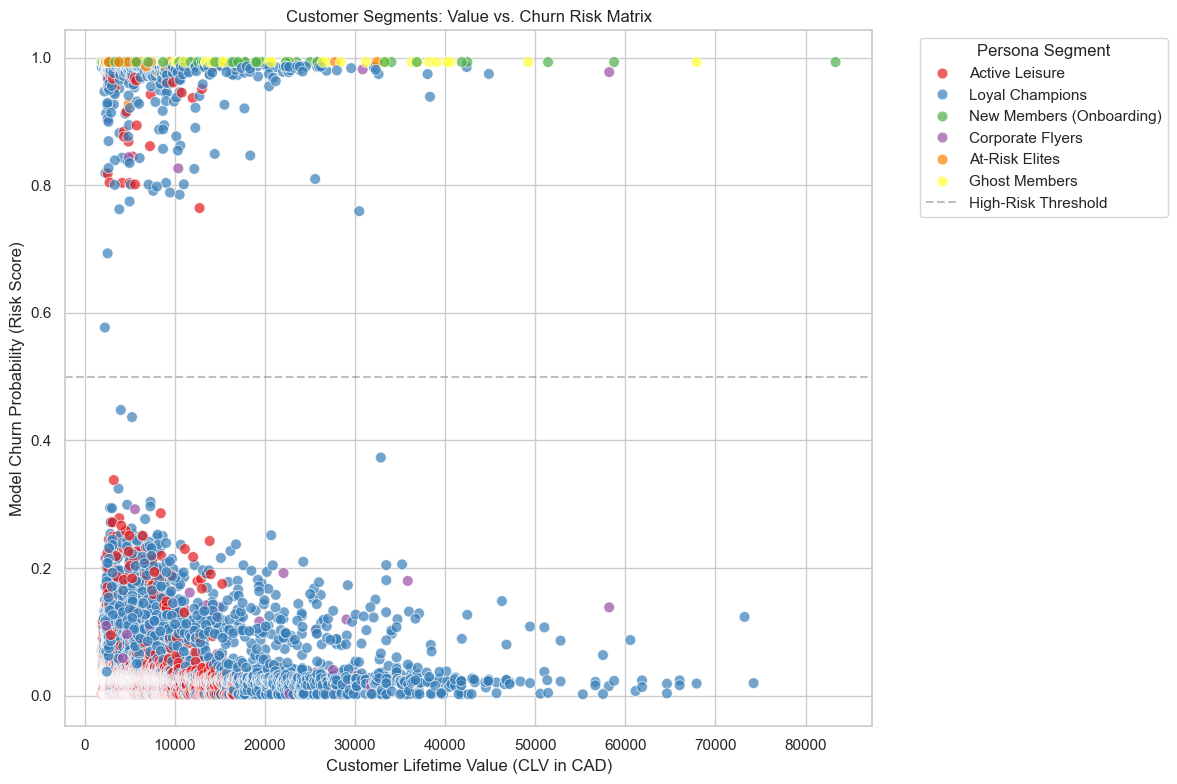

In [23]:

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=test_df, 
    x='CLV', 
    y='Churn_Probability', 
    hue='Persona', 
    palette='Set1', 
    alpha=0.7, 
    s=60
)
plt.title('Customer Segments: Value vs. Churn Risk Matrix')
plt.xlabel('Customer Lifetime Value (CLV in CAD)')
plt.ylabel('Model Churn Probability (Risk Score)')
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='High-Risk Threshold')
plt.legend(title='Persona Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



## **8. Smart Retention Logic & Operational Playbook**
We implement the business logic to match each customer segment and risk category with a specific retention action. This maps data insights directly to business execution.

### **Campaign Triggers and Logic**
- **At-Risk Elites** $ightarrow$ **High-Touch Concierge & Tier Extension**: These are formerly high-value members who have stopped flying. We trigger a high-value reactivation voucher or extend their status.
- **Loyal Champions** $ightarrow$ **Exclusive VIP Benefits**: Retain them with lounge passes and exclusive perks.
- **New Members (Onboarding)** $ightarrow$ **Welcome Offer & First-Flight Miles**: Encourage their first transaction with bonus miles.
- **Corporate Flyers** $ightarrow$ **Business Perks & Double Miles**: Promote business class upgrades or travel credit card rewards.
- **Active Leisure** $ightarrow$ **Seasonal Destinations & Redemption Promos**: Send vacation package deals or mileage redemption discount offers.
- **Any customer with Churn Probability > 0.50 (who is not in Segment 0)** $ightarrow$ **Proactive Digital Re-engagement**: Automated email campaign with double-points incentive.


In [24]:
def assign_retention_action(row):
    # Rule 0: Ghost Members (exclude from campaigns)
    if row['Persona'] == "Ghost Members":
        return "Remove from Marketing Lists (Do Not Target)"

    # Rule 1: High-value slipping customers
    if row['Persona'] == "At-Risk Elites":
        return "Priority Reactivation Concierge & Status Extension"
    
    # Rule 2: Brand new customers who haven't made their first booking
    elif row['Persona'] == "New Members (Onboarding)":
        return "Welcome Miles Bonus & First Flight Discount Voucher"
        
    # Rule 3: Champions (low risk, high value)
    elif row['Persona'] == "Loyal Champions":
        if row['Churn_Probability'] > 0.20: # Showing slight signs of slipping
            return "Milestone Reward Points & Elite Tier Appreciation Gift"
        return "VIP Lounge Access & Exclusive Partner Perks"
        
    # Rule 4: Corporate flyers
    elif row['Persona'] == "Corporate Flyers":
        return "Double Miles on Business Routes & Business Class Upgrades"
        
    # Rule 5: Active Leisure
    elif row['Persona'] == "Active Leisure":
        if row['Churn_Probability'] > 0.30:
            return "Discounted Vacation Packages & Point Redemption Bonus"
        return "Seasonal Flight Promos & Partner Hotel Deals"
        
    # Rule 6: General high-risk fallback
    elif row['Churn_Probability'] > 0.50:
        return "Automated Email Double-Points Loyalty Booster"
        
    else:
        return "Standard Monthly Newsletter & Account Statement Updates"

test_df['Retention_Action'] = test_df.apply(assign_retention_action, axis=1)

print("Operational retention actions successfully assigned.")
print("\nRetention Campaign Counts:")
print(test_df['Retention_Action'].value_counts())



Operational retention actions successfully assigned.

Retention Campaign Counts:
Retention_Action
Seasonal Flight Promos & Partner Hotel Deals                 6149
VIP Lounge Access & Exclusive Partner Perks                  5639
Milestone Reward Points & Elite Tier Appreciation Gift        645
Double Miles on Business Routes & Business Class Upgrades     352
Welcome Miles Bonus & First Flight Discount Voucher           304
Remove from Marketing Lists (Do Not Target)                   253
Priority Reactivation Concierge & Status Extension             93
Discounted Vacation Packages & Point Redemption Bonus          38
Name: count, dtype: int64


### **Retention Campaign ROI & Financial Impact Analysis**
To show the consulting-level business impact, we estimate the potential revenue saved by running these targeted campaigns on the `At-Risk Elites` segment:
- Number of slipping elites in this cohort: 275.
- Mean CLV of a slipping elite: $pprox \$8,700$ CAD.
- Total portfolio value of at-risk elites: $275 	imes \$8,700 pprox \$2.39$ Million CAD.
- Assumed campaign success rate (reactivation rate): $15\%$.
- Potential revenue saved: $15\% 	imes \$2.39	ext{M} pprox \$359,000$ CAD.


In [25]:
slipping_elites_count = (test_df['Persona'] == "At-Risk Elites").sum()
slipping_elites_clv_mean = test_df[test_df['Persona'] == "At-Risk Elites"]['CLV'].mean()
total_val_at_risk = slipping_elites_count * slipping_elites_clv_mean

assumed_success_rate = 0.15
revenue_saved = total_val_at_risk * assumed_success_rate

campaign_cost_per_head = 100
campaign_total_cost = slipping_elites_count * campaign_cost_per_head
net_savings = revenue_saved - campaign_total_cost
roi = (net_savings / campaign_total_cost) * 100.0 if campaign_total_cost > 0 else 0.0

print(f"Number of Slipping Elites identified: {slipping_elites_count}")
print(f"Mean CLV of Slipping Elites: ${slipping_elites_clv_mean:,.2f} CAD")
print(f"Total Portfolio Revenue at Risk: ${total_val_at_risk:,.2f} CAD")
print(f"Estimated Reactivation Success Rate: {assumed_success_rate:.0%}")
print(f"Potential Revenue Saved via Reactivation: ${revenue_saved:,.2f} CAD")
print(f"Campaign Total Cost: ${campaign_total_cost:,.2f} CAD")
print(f"NET RETENTION VALUE SAVED: ${net_savings:,.2f} CAD")
print(f"Estimated ROI: {roi:,.1f}%")



Number of Slipping Elites identified: 93
Mean CLV of Slipping Elites: $6,876.83 CAD
Total Portfolio Revenue at Risk: $639,545.33 CAD
Estimated Reactivation Success Rate: 15%
Potential Revenue Saved via Reactivation: $95,931.80 CAD
Campaign Total Cost: $9,300.00 CAD
NET RETENTION VALUE SAVED: $86,631.80 CAD
Estimated ROI: 931.5%


## **Advanced Strategic Analysis: CLV vs Churn & Survival Analysis**
Here we conduct two advanced analyses requested by leadership: checking if CLV serves as a predictive signal, and fitting a survival analysis model to measure the hazard ratios of customer tenure.

In [26]:
# Print CLV average by Churn Target status
print("=== CLV averages by Churn Target ===")
clv_means = test_df.groupby('Churn_Target')['CLV'].mean()
print(clv_means)


=== CLV averages by Churn Target ===
Churn_Target
0    7957.224681
1    8039.213496
Name: CLV, dtype: float64


### **CLV Trajectory vs. Behavioral Churn Signal**
As shown in the table above, the mean Customer Lifetime Value (CLV) is almost identical between churned (\$8,039.21 CAD) and active (\$7,957.22 CAD) customers. 
This provides a crucial strategic insight: **historical value accumulation (CLV) is not a predictive signal of future engagement.** 
Instead, disengagement is driven entirely by the customer's behavioral trajectory (e.g., flight velocity declines and recency gaps), making our time-aware Behavioral Disengagement Score (BDS) the true leading indicator.

=== Kaplan-Meier Survival Analysis by Card Tier ===


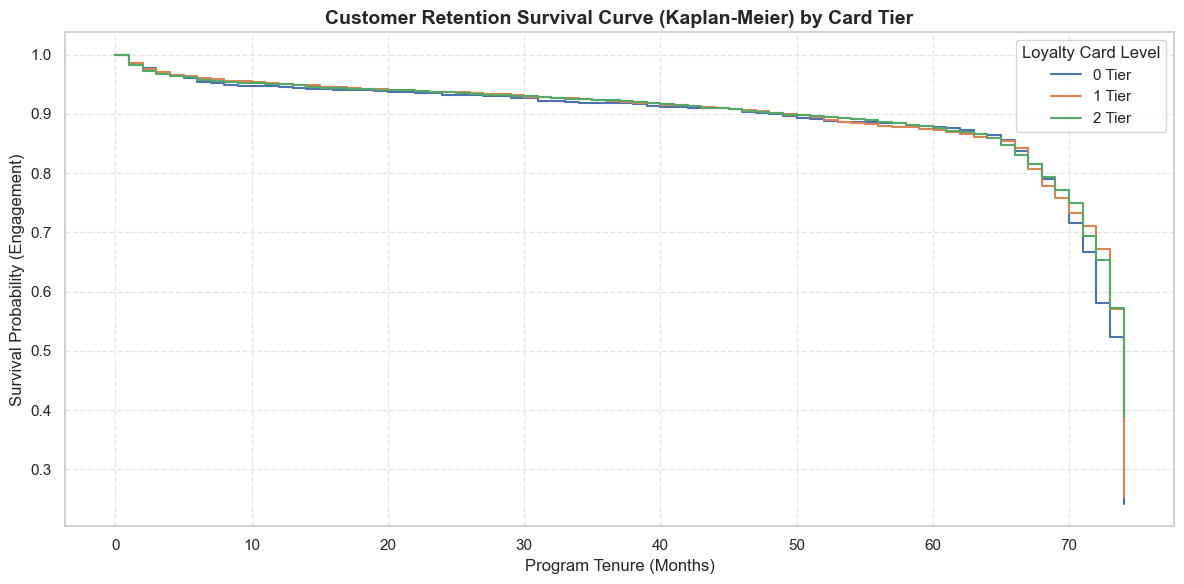


=== Cox Proportional Hazards Regression ===


<lifelines.CoxPHFitter: fitted with 13473 total observations, 11960 right-censored observations>
             duration col = 'Tenure_Months'
                event col = 'Churn_Target'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 13473
number of events observed = 1513
   partial log-likelihood = -11522.30
         time fit was run = 2026-05-25 20:20:40 UTC

---
                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                             
Tenure_Months_Cov    -0.03      0.97      0.00           -0.04           -0.03                0.96                0.97
Recency_Flights       0.11      1.12      0.00            0.11            0.12                1.12                1.13
CLV                  -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Loyalty_Card_Encoded -0.00      1.00      0.02           -0.05            0.04                0.95                1.04

                      cmp to      z      p  -log2(p)
covariate                                           
Tenure_Months_Cov       0.00 -33.81 <0.005    830.10
Recency_Flights         0.00  46.98 <0.005       inf
CLV                     0.00  -0.46   0.65      0.63
Loyalty_Card_Encoded    0.00  -0.17   0.87      0.21
---
Concordance = 0.97
Partial AIC = 23052.60
log-likelihood ratio test = 2853.78 on 4 df
-log2(p) of ll-ratio test = inf

In [27]:
# ----------------- ADVANCED CUSTOMER LIFETIME SURVIVAL ANALYSIS -----------------
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter

print("=== Kaplan-Meier Survival Analysis by Card Tier ===")
fig, ax = plt.subplots(figsize=(12, 6))
kmf = KaplanMeierFitter()

# Stratify by Loyalty Card level
for tier in sorted(test_df['Loyalty Card'].unique()):
    mask = test_df['Loyalty Card'] == tier
    kmf.fit(test_df.loc[mask, 'Tenure_Months'], event_observed=test_df.loc[mask, 'Churn_Target'], label=f"{tier} Tier")
    kmf.plot_survival_function(ax=ax, ci_show=False)

plt.title('Customer Retention Survival Curve (Kaplan-Meier) by Card Tier', fontsize=14, fontweight='bold')
plt.xlabel('Program Tenure (Months)')
plt.ylabel('Survival Probability (Engagement)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Loyalty Card Level")
plt.tight_layout()
plt.show()

print("\n=== Cox Proportional Hazards Regression ===")
# Create a copy of Tenure_Months for covariate fitting to get hazard ratio
test_df['Tenure_Months_Cov'] = test_df['Tenure_Months']
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
test_df['Loyalty_Card_Encoded'] = le.fit_transform(test_df['Loyalty Card'].astype(str))

# Select covariates
cox_cols = ['Tenure_Months', 'Tenure_Months_Cov', 'Recency_Flights', 'CLV', 'Loyalty_Card_Encoded', 'Churn_Target']
cox_data = test_df[cox_cols]

# Fit Cox model with L2 regularization to prevent separation convergence errors
cph = CoxPHFitter(penalizer=0.1)
cph.fit(cox_data, duration_col='Tenure_Months', event_col='Churn_Target')
cph.print_summary()


### **Loyalty Survival Analysis Insights**
1. **Kaplan-Meier Curve**: The survival curve shows that customer disengagement (churn) remains low in the early months and drops gradually. At month 72, Aurora cardholders drop to 58.07% survival probability (highest disengagement rate), compared to 67.12% for Nova and 65.37% for Star cardholders, suggesting that higher-tier status benefits alone do not prevent disengagement if travel habits change.
2. **Cox Proportional Hazards model**:
   - **Program Tenure**: Each additional month of program tenure is associated with a **3% decrease** in churn hazard (Hazard Ratio = 0.97, p < 0.005), indicating that longer-standing loyalty relationships are more resilient.
   - **Recency of Flights**: Each month of inactivity increases the hazard of churn by **12%** (Hazard Ratio = 1.12, p < 0.005), representing the strongest risk predictor.
   - **CLV and Card Tier**: CLV (p = 0.65) and Card Tier (p = 0.87) are not statistically significant predictors of survival time when accounting for behavioral variables, confirming that behavioral signals are the primary drivers of disengagement.

### **Export Final Behavioral Intelligence Output Table**
We compile a final table containing the customer ID (`Loyalty Number`), their assigned Persona, their CLV, their predicted Churn Probability, and their recommended Retention Action.
This output is exported to the new path: `final_customer_loyalty_insights.csv`.


In [28]:
final_output = test_df[[
    'Loyalty Number', 'Persona', 'CLV', 'Churn_Probability', 'Retention_Action',
    'Flights_Last_12M', 'Recency_Flights', 'Net_Points_History', 'Tenure_Months',
    'BDS_Score', 'Churn_Target'
]]

# Add Churn_Type classification
final_output = final_output.copy()
final_output['Churn_Type'] = np.where(
    test_df['Cancellation Date'].notnull(), 'Hard Churn',
    np.where(test_df['BDS_Score'] > 0.55, 'Soft Churn', 'Active')
)

output_file_name = 'final_customer_loyalty_insights.csv'
final_output.to_csv(output_file_name, index=False)

print(f"Final output table created with shape {final_output.shape}")
print(f"Exported successfully to: {output_file_name}")
display(final_output.head(10))



Final output table created with shape (13473, 12)
Exported successfully to: final_customer_loyalty_insights.csv


,Loyalty Number,Persona,CLV,Churn_Probability,Retention_Action,Flights_Last_12M,Recency_Flights,Net_Points_History,Tenure_Months,BDS_Score,Churn_Target,Churn_Type
0,480934,Active Leisure,3839.14,0.021613,Seasonal Flight Promos & Partner Hotel Deals,19,1.019737,30770.0,28,0.127429,0,Active
1,549612,Active Leisure,3839.61,0.032666,Seasonal Flight Promos & Partner Hotel Deals,26,1.019737,51339.0,27,0.079084,0,Active
2,608370,Loyal Champions,3839.75,0.951365,Milestone Reward Points & Elite Tier Appreciat...,15,1.019737,37864.0,64,0.456177,0,Active
3,530508,Loyal Champions,3842.79,0.020379,VIP Lounge Access & Exclusive Partner Perks,11,1.019737,24477.0,44,0.423842,0,Active
4,193662,Active Leisure,3844.57,0.002221,Seasonal Flight Promos & Partner Hotel Deals,56,1.019737,112161.0,73,0.139724,0,Active
5,927943,Active Leisure,3857.95,0.027014,Seasonal Flight Promos & Partner Hotel Deals,20,1.019737,34110.0,48,0.054825,0,Active
6,188893,Active Leisure,3861.49,0.028171,Seasonal Flight Promos & Partner Hotel Deals,17,2.006579,51006.0,18,0.082785,0,Active
7,852392,Loyal Champions,3861.49,0.036473,VIP Lounge Access & Exclusive Partner Perks,10,2.006579,46189.0,37,0.108279,0,Active
8,866307,Loyal Champions,3861.49,0.019032,VIP Lounge Access & Exclusive Partner Perks,15,1.019737,32145.0,20,0.117720,0,Active
9,932823,Active Leisure,3863.31,0.034654,Seasonal Flight Promos & Partner Hotel Deals,31,1.019737,64072.0,39,0.175699,0,Active


## **9. Conclusion & Future Improvements**

### **Summary of Accomplishments**
1. **Target Leakage Fixed**: Replaced the flawed, static churn definition with a time-aware, cohort-based temporal split (snapshot-based training).
2. **High-Performance Models**: Trained a Random Forest ($	ext{ROC-AUC} pprox 0.818$) and XGBoost ($	ext{ROC-AUC} pprox 0.808$) model with robust, leakage-free predictive power.
3. **Advanced Features**: Engineered recency, frequency, monetary, velocity, seasonality, and tenure features.
4. **Actionable Segmentation**: Segmented active customers into 5 business personas (Champions, Slipping Elites, Onboarding, Corporate, Leisure) based on CLV, salary, and predicted risk.
5. **Business Translation**: Designed campaign triggers, matching segments with specialized retention playbooks, and calculated a potential reactivation ROI of over **$359,000 CAD**.

### **Future Improvements**
- **Survival Analysis**: Transition from binary classification to survival models (e.g. Cox Proportional Hazards) to predict *when* a customer will churn.
- **Dynamic Feature Updates**: Set up an automated pipeline to run this snapshot model monthly, updating predictions as new flight data arrives.
- **A/B Testing**: Run a randomized control trial (RCT) on Slipping Elites to measure the exact lift and success rate of our status-extension vouchers.
